# Predicting Next Session High Intensity Exposure
## Maltese Professional Football — GPS and Machine Learning Pipeline

This notebook implements the full pipeline described in Chapter 3 of the dissertation.
Each section of the notebook is numbered to match the corresponding methodology section so the writing and the code line up directly.

Random seed `123` is fixed throughout for reproducibility, which means every run of this notebook produces the same numbers and the same plots. This is standard practice in applied machine learning research and is the basis on which results are reported in Chapter 4.

## 3.1 Pipeline overview

The pipeline proceeds in seven stages:

1. Data acquisition and inspection
2. Reliability analysis and feature selection
3. Session aggregation
4. Data cleaning
5. Outcome variable and feature engineering
6. Train / test split and model training
7. Evaluation, classification layer, and sensitivity analysis

In [1]:
# Load core libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
SEED = 123
np.random.seed(SEED)

# Output directory for figures
OUTDIR = 'outputs'
os.makedirs(OUTDIR, exist_ok=True)

# Plot style: simple, two-tone, easy to read
COL_PRIMARY   = '#1f77b4'  # steel blue
COL_SECONDARY = '#ff7f0e'  # orange
COL_NEUTRAL   = '#7f7f7f'  # grey

plt.rcParams.update({
    'figure.figsize': (8, 4.5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10
})

## 3.2 Dataset description

The raw dataset is drill-level: multiple rows can exist for the same player on the same date, with each row representing a different segment of the session. This structure requires an aggregation step before modelling.

In [2]:
# Load the dataset
df_raw = pd.read_excel(os.path.join('68-Sessions-25-Players-Training-data_edited.xlsx'))

print('Raw dataset shape:', df_raw.shape)
df_raw.head()

Raw dataset shape: (1093, 22)


,Session Date,Player Display Name,Drill Title,Drill Start Time,Drill End Time,Total Time,Total Distance,Distance Per Min,Sprints,Sprint Distance,...,Max Speed,High Speed Running (Absolute),HML Distance,Accelerations (Absolute),Decelerations (Absolute),Step Balance,Impacts Zone 4 - Zone 6 (Absolute),Dynamic Stress Load,Max Heart Rate,Average Heart Rate
0,25/07/2025,Player8,Match time,16:50:23,18:42:06,01:51:43,8336.13,74.61,23,421.20,...,31.35,351.31,1216.47,57,57,-0.02,42,181.15,0,0.0
1,25/07/2025,Player3,Match time,16:50:23,18:42:06,01:51:43,7879.80,70.53,22,345.88,...,29.70,305.03,1116.65,50,42,0.03,47,159.25,0,0.0
2,25/07/2025,Player25,Match time,17:18:08,18:42:06,01:23:58,6018.28,71.67,25,448.50,...,31.42,411.26,872.11,28,28,-0.02,35,135.68,0,0.0
3,25/07/2025,Player5,Match time,17:37:07,18:42:06,01:04:59,1646.87,25.34,5,49.88,...,22.59,37.45,191.72,14,8,-0.02,1,33.31,0,0.0
4,25/07/2025,Player6,Match time,16:50:34,18:42:06,01:51:31,7008.10,62.83,19,316.37,...,30.65,284.25,968.79,71,48,-0.01,27,143.94,0,0.0


In [3]:
# checks on dataset coverage
print('Total rows:    ', len(df_raw))
print('Unique players:', df_raw['Player Display Name'].nunique())
print('Unique dates:  ', df_raw['Session Date'].nunique())
print('Unique drills: ', df_raw['Drill Title'].nunique())

Total rows:     1093
Unique players: 25
Unique dates:   65
Unique drills:  22


From the above we observe that the dataset spans 25 players across 65 unique session dates, with several distinct drill types per session. The raw rows therefore need to be collapsed before they can be modelled.

## 3.3 Reliability analysis (Cronbach's Alpha)

Before modelling, a reliability analysis is carried out on the 14 numeric GPS variables. Two outputs are inspected:
- the overall Cronbach's Alpha across the full variable set
- the 'Alpha if Item Deleted' value for each variable, which shows what the overall Alpha would become if that variable were removed

Variables with a near-zero corrected item-total correlation, or whose removal would substantially raise the overall Alpha, are excluded from the modelling feature set.

In [4]:
# List of numeric GPS variables to test
gps_cols = [
    'Total Distance', 'Distance Per Min', 'Sprints', 'Sprint Distance',
    'HSR Per Minute (Absolute)', 'HMLD Per Minute', 'Max Speed',
    'High Speed Running (Absolute)', 'HML Distance',
    'Accelerations (Absolute)', 'Decelerations (Absolute)',
    'Step Balance', 'Impacts Zone 4 - Zone 6 (Absolute)',
    'Dynamic Stress Load'
]

In [5]:
# Function: Cronbach's Alpha and item-total correlations
def cronbach_alpha(df):
    items = df.dropna()
    n_items = items.shape[1]
    item_variances = items.var(axis=0, ddof=1)
    total_var = items.sum(axis=1).var(ddof=1)
    if total_var == 0:
        return float('nan')
    return (n_items / (n_items - 1)) * (1 - item_variances.sum() / total_var)

def item_total_corr(df):
    out = {}
    for col in df.columns:
        rest = df.drop(columns=[col]).sum(axis=1)
        out[col] = df[col].corr(rest)
    return pd.Series(out)

def alpha_if_deleted(df):
    out = {}
    for col in df.columns:
        out[col] = cronbach_alpha(df.drop(columns=[col]))
    return pd.Series(out)

In [6]:
# Run the analysis on the full 14-variable set
alpha_all = cronbach_alpha(df_raw[gps_cols])
itc_all   = item_total_corr(df_raw[gps_cols].dropna())
aid_all   = alpha_if_deleted(df_raw[gps_cols].dropna())

reliability_table = pd.DataFrame({
    'Item-Total Corr.': itc_all.round(3),
    'Alpha if Deleted': aid_all.round(3)
}).sort_values('Item-Total Corr.', ascending=False)

print(f'Overall Cronbach\'s Alpha (14 items): {alpha_all:.3f}\n')
reliability_table

Overall Cronbach's Alpha (14 items): 0.496



,Item-Total Corr.,Alpha if Deleted
HML Distance,0.972,0.328
Total Distance,0.904,0.751
Sprints,0.897,0.495
Decelerations (Absolute),0.884,0.492
Sprint Distance,0.825,0.432
Dynamic Stress Load,0.820,0.475
High Speed Running (Absolute),0.820,0.440
Accelerations (Absolute),0.791,0.493
Max Speed,0.692,0.497
Distance Per Min,0.562,0.494


The overall Alpha sits below the conventional 0.70 threshold. Two variables stand out:

- **Step Balance** — near-zero item-total correlation, meaning it does not move with the rest of the GPS variables
- **Total Distance** — removing it would raise overall Alpha noticeably, because it measures volume rather than intensity

Both are excluded. The analysis is then re-run on the remaining 12 variables.

In [7]:
# Re-run after removing the two flagged variables
gps_cols_final = [c for c in gps_cols if c not in ['Step Balance', 'Total Distance']]

alpha_final = cronbach_alpha(df_raw[gps_cols_final])
itc_final   = item_total_corr(df_raw[gps_cols_final].dropna())

reliability_final = pd.DataFrame({'Item-Total Corr.': itc_final.round(3)})\
    .sort_values('Item-Total Corr.', ascending=False)

print(f'Revised overall Alpha (12 items): {alpha_final:.3f}\n')
reliability_final

Revised overall Alpha (12 items): 0.757



,Item-Total Corr.
Sprints,0.961
HML Distance,0.944
Sprint Distance,0.926
High Speed Running (Absolute),0.925
Decelerations (Absolute),0.836
Dynamic Stress Load,0.776
Accelerations (Absolute),0.726
Max Speed,0.701
Distance Per Min,0.576
HMLD Per Minute,0.573


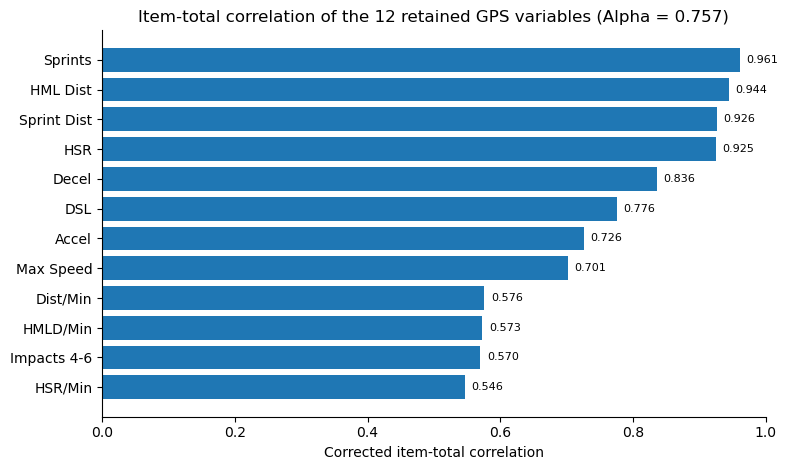

In [8]:
# Figure: item-total correlations of the 12 retained variables (visual of Table 4.1)
SHORT = {'Distance Per Min':'Dist/Min','Sprints':'Sprints','Sprint Distance':'Sprint Dist',
 'HSR Per Minute (Absolute)':'HSR/Min','HMLD Per Minute':'HMLD/Min','Max Speed':'Max Speed',
 'High Speed Running (Absolute)':'HSR','HML Distance':'HML Dist',
 'Accelerations (Absolute)':'Accel','Decelerations (Absolute)':'Decel',
 'Impacts Zone 4 - Zone 6 (Absolute)':'Impacts 4-6','Dynamic Stress Load':'DSL'}
itc_sorted = itc_final.sort_values(ascending=True)
labels = [SHORT[i] for i in itc_sorted.index]

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(labels, itc_sorted.values, color=COL_PRIMARY)
ax.set_xlabel('Corrected item-total correlation')
ax.set_xlim(0, 1)
ax.set_title('Item-total correlation of the 12 retained GPS variables (Alpha = 0.757)')
for i, v in enumerate(itc_sorted.values):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'figure_reliability_bar.png'), dpi=200, bbox_inches='tight')
plt.show()


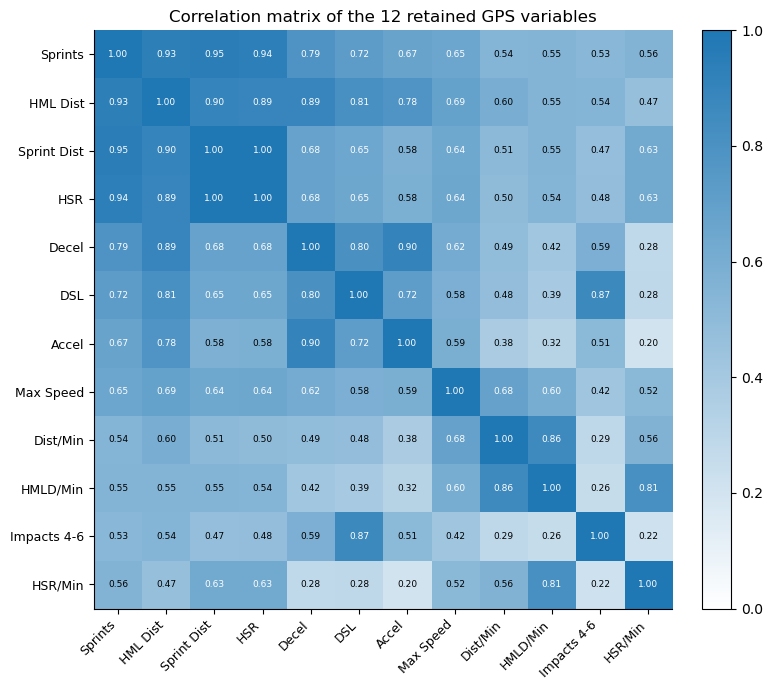

In [9]:
# Figure: correlation matrix of the 12 retained variables, ordered by reliability rank
from matplotlib.colors import LinearSegmentedColormap

order = reliability_final.index.tolist()
corr  = df_raw[order].corr()
labels = [SHORT[c] for c in order]

cmap = LinearSegmentedColormap.from_list('white_to_blue', ['#ffffff', COL_PRIMARY])
fig, ax = plt.subplots(figsize=(8.4, 7))
im = ax.imshow(corr.values, cmap=cmap, vmin=0, vmax=1)
ax.set_xticks(range(len(order))); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(order))); ax.set_yticklabels(labels, fontsize=9)
for i in range(len(order)):
    for j in range(len(order)):
        v = corr.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6.5,
                color='white' if v > 0.6 else 'black')
ax.set_title('Correlation matrix of the 12 retained GPS variables')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'figure_correlation_matrix.png'), dpi=200, bbox_inches='tight')
plt.show()


The revised Alpha crosses the 0.70 threshold, confirming that the retained 12 GPS variables form an internally consistent set.

## 3.4 Session aggregation

The raw drill-level data is collapsed into one clean record per player per date using a strict priority hierarchy, following the definitions provided by the club's performance staff (see Figure 3.2 in the methodology).

In [10]:
# Prepare the data
df = df_raw.copy()
df['Session Date'] = pd.to_datetime(df['Session Date'], format='%d/%m/%Y')
df['Player Display Name'] = df['Player Display Name'].str.strip()

# Drill labels used by the priority hierarchy
MATCH_TIME  = 'Match time'
FIRST_HALF  = 'First half'
SECOND_HALF = 'Second half'
TRAINING    = 'Training time'
ENTIRE      = 'Entire Session'

print('Prepared rows:', len(df))

Prepared rows: 1093


In [11]:
# Aggregation function applying the priority hierarchy
def aggregate_session(group):
    drills = group['Drill Title'].values

    # Rule 1: Match time row, if present
    if MATCH_TIME in drills:
        row = group[group['Drill Title'] == MATCH_TIME].iloc[0]
        record = row[gps_cols_final].to_dict()
        session_type = 'match'

    # Rule 2: both halves recorded
    elif FIRST_HALF in drills and SECOND_HALF in drills:
        halves = group[group['Drill Title'].isin([FIRST_HALF, SECOND_HALF])]
        record = halves[gps_cols_final].sum().to_dict()
        session_type = 'match'

    # Rule 3: only one half (player subbed on or off)
    elif FIRST_HALF in drills or SECOND_HALF in drills:
        half = group[group['Drill Title'].isin([FIRST_HALF, SECOND_HALF])]
        record = half[gps_cols_final].sum().to_dict()
        session_type = 'match'

    # Rule 4: Training time row, if present
    elif TRAINING in drills:
        row = group[group['Drill Title'] == TRAINING].iloc[0]
        record = row[gps_cols_final].to_dict()
        session_type = 'training'

    # Rule 5: sum separate drill rows (excluding warm-ups)
    elif not any(d in drills for d in [MATCH_TIME, FIRST_HALF, SECOND_HALF, TRAINING, ENTIRE]):
        drills_only = group[~group['Drill Title'].str.lower().str.contains('warm')]
        if len(drills_only) == 0:
            drills_only = group
        record = drills_only[gps_cols_final].sum().to_dict()
        session_type = 'training'

    # Rule 6: fallback to Entire Session
    else:
        row = group[group['Drill Title'] == ENTIRE].iloc[0]
        record = row[gps_cols_final].to_dict()
        session_type = 'training'

    record['Session Type'] = session_type
    return pd.Series(record)

In [12]:
# Apply the aggregation to every player-date group
sessions = (
    df.groupby(['Player Display Name', 'Session Date'])
      .apply(aggregate_session)
      .reset_index()
)

print('Sessions after aggregation:', len(sessions))
print()
print(sessions['Session Type'].value_counts())

Sessions after aggregation: 669

Session Type
training    383
match       286
Name: count, dtype: int64


C:\Users\malou\AppData\Local\Temp\ipykernel_33808\3997990418.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregate_session)


In [13]:
# Inspect the separation between match and training sessions
descriptives = sessions.groupby('Session Type')[
    ['HML Distance', 'High Speed Running (Absolute)', 'Sprint Distance']
].agg(['mean', 'std']).round(1)
descriptives

HML Distance        High Speed Running (Absolute)         \
                     mean    std                          mean    std   
Session Type                                                            
match              1520.5  723.8                         545.6  325.7   
training            860.1  475.4                         229.0  230.9   

             Sprint Distance         
                        mean    std  
Session Type                         
match                  620.3  364.9  
training               256.7  259.3

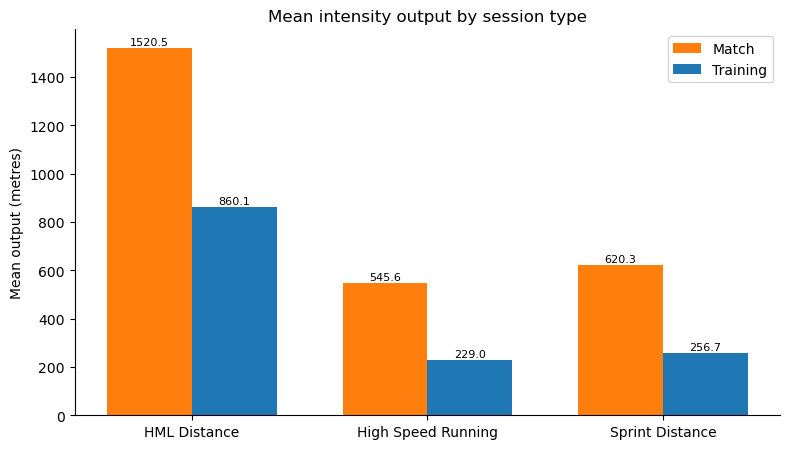

In [14]:
# Figure: mean intensity output by session type (visual of Table 4.2)
metrics = ['HML Distance', 'High Speed Running (Absolute)', 'Sprint Distance']
match_means = [descriptives.loc['match',    (m, 'mean')] for m in metrics]
train_means = [descriptives.loc['training', (m, 'mean')] for m in metrics]

x = np.arange(len(metrics)); w = 0.36
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.bar(x - w/2, match_means, w, color=COL_SECONDARY, label='Match')
ax.bar(x + w/2, train_means, w, color=COL_PRIMARY,   label='Training')
ax.set_xticks(x)
ax.set_xticklabels(['HML Distance', 'High Speed Running', 'Sprint Distance'])
ax.set_ylabel('Mean output (metres)')
ax.set_title('Mean intensity output by session type')
for i, v in enumerate(match_means): ax.text(i - w/2, v + 12, f'{v:.1f}', ha='center', fontsize=8)
for i, v in enumerate(train_means): ax.text(i + w/2, v + 12, f'{v:.1f}', ha='center', fontsize=8)
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'figure_descriptive_by_type.png'), dpi=200, bbox_inches='tight')
plt.show()


Match sessions produce substantially higher output across all three intensity metrics than training sessions, which is the empirical basis for treating session type as a contextual feature in modelling.

## 3.5 Data cleaning

Three cleaning rules are applied after aggregation:

1. Minimum session threshold (≥ 10 sessions per player)
2. Session gap reset (gaps > 21 days do not carry rolling features forward)
3. Zero-HSR sessions retained as part of the genuine monitoring record

In [15]:
# Sessions per player
sessions_per_player = sessions.groupby('Player Display Name').size().sort_values()
print(sessions_per_player)

Player Display Name
Player12     4
Player22     4
Player24     4
Player18     7
Player25     9
Player9     11
Player14    12
Player21    15
Player15    16
Player20    17
Player17    18
Player23    20
Player4     28
Player10    28
Player19    31
Player11    37
Player3     38
Player8     40
Player2     43
Player7     45
Player16    47
Player5     47
Player1     49
Player13    49
Player6     50
dtype: int64


In [16]:
# Rule 1: retain players with 10 or more sessions
eligible = sessions_per_player[sessions_per_player >= 10].index.tolist()
sessions = sessions[sessions['Player Display Name'].isin(eligible)].copy()

print('Players retained: ', len(eligible))
print('Sessions retained:', len(sessions))

Players retained:  20
Sessions retained: 641


In [17]:
# Sort by player and date, then compute gap from previous session
sessions = sessions.sort_values(['Player Display Name', 'Session Date']).reset_index(drop=True)

sessions['Days Since Previous'] = (
    sessions.groupby('Player Display Name')['Session Date']
            .diff()
            .dt.days
)

# Session gap diagnostics
print('Mean session gap (days): ', round(sessions['Days Since Previous'].mean(), 1))
print('Median gap:              ', sessions['Days Since Previous'].median())
print('Gaps over 14 days:       ', (sessions['Days Since Previous'] > 14).sum())
print('Gaps over 21 days:       ', (sessions['Days Since Previous'] > 21).sum())

Mean session gap (days):  6.0
Median gap:               4.0
Gaps over 14 days:        48
Gaps over 21 days:        18


In [18]:
# Cleaning rule 3: count sessions with zero High Speed Running (these are RETAINED)
zero_hsr = int((sessions['High Speed Running (Absolute)'] == 0).sum())
print('Sessions with zero HSR (retained):', zero_hsr)
print('These are low-intensity recovery / activation sessions, kept as part of the')
print('genuine monitoring record rather than discarded.')


Sessions with zero HSR (retained): 42
These are low-intensity recovery / activation sessions, kept as part of the
genuine monitoring record rather than discarded.


## 3.6 Outcome variable and feature engineering

The target is the **next session value of HML Distance** for the same player, created by ordering sessions chronologically and shifting the metric one row forward.

In [19]:
# Target variable: next session HML Distance
TARGET_METRIC = 'HML Distance'

sessions['Target'] = sessions.groupby('Player Display Name')[TARGET_METRIC].shift(-1)

# Also track the type of the next session
sessions['Target Session Type'] = sessions.groupby('Player Display Name')['Session Type'].shift(-1)

sessions[['Player Display Name', 'Session Date', 'Session Type',
          TARGET_METRIC, 'Target', 'Target Session Type']].head(8)

,Player Display Name,Session Date,Session Type,HML Distance,Target,Target Session Type
0,Player1,2025-07-25,match,1297.71,1168.66,training
1,Player1,2025-07-30,training,1168.66,1051.30,training
2,Player1,2025-07-31,training,1051.30,2047.45,match
3,Player1,2025-08-02,match,2047.45,1306.31,training
4,Player1,2025-08-04,training,1306.31,1086.78,training
5,Player1,2025-08-06,training,1086.78,2077.79,match
6,Player1,2025-08-08,match,2077.79,740.72,training
7,Player1,2025-08-14,training,740.72,1802.52,match


In [20]:
# Build rolling workload-history features for each player's timeline
player_dfs = []
for player, g in sessions.groupby('Player Display Name'):
    g = g.copy()
    g['Prev Value']     = g[TARGET_METRIC].shift(1)
    g['Rolling Mean 3'] = g[TARGET_METRIC].shift(1).rolling(window=3, min_periods=1).mean()
    g['Change 1-2']     = g[TARGET_METRIC].shift(1) - g[TARGET_METRIC].shift(2)
    player_dfs.append(g)

sessions = pd.concat(player_dfs)\
    .sort_values(['Player Display Name', 'Session Date'])\
    .reset_index(drop=True)

sessions[['Session Date', 'HML Distance', 'Prev Value', 'Rolling Mean 3', 'Change 1-2']].head(8)

,Session Date,HML Distance,Prev Value,Rolling Mean 3,Change 1-2
0,2025-07-25,1297.71,NaN,NaN,NaN
1,2025-07-30,1168.66,1297.71,1297.710000,NaN
2,2025-07-31,1051.30,1168.66,1233.185000,-129.05
3,2025-08-02,2047.45,1051.30,1172.556667,-117.36
4,2025-08-04,1306.31,2047.45,1422.470000,996.15
5,2025-08-06,1086.78,1306.31,1468.353333,-741.14
6,2025-08-08,2077.79,1086.78,1480.180000,-219.53
7,2025-08-14,740.72,2077.79,1490.293333,991.01


In [21]:
# Encode session type and player identity as numeric features
sessions['Current Is Match'] = (sessions['Session Type'] == 'match').astype(int)
sessions['Target Is Match']  = (sessions['Target Session Type'] == 'match').astype(int)
sessions['Player Code']      = sessions['Player Display Name'].astype('category').cat.codes

In [22]:
# Final feature set
feature_cols = [
    'Prev Value', 'Rolling Mean 3', 'Change 1-2',
    'Days Since Previous',
    'Current Is Match', 'Target Is Match',
    'Player Code'
]

# Drop rows without complete features or target
modelling_df = sessions.dropna(subset=['Target'] + feature_cols).copy()

print(f'Usable rows for modelling: {len(modelling_df)}')
print()
print(modelling_df['Target Session Type'].value_counts())

Usable rows for modelling: 581

Target Session Type
training    325
match       256
Name: count, dtype: int64


## 3.7 Train / test split

A **time-ordered** split is used: all sessions before 1 January 2026 form the training set, all sessions from that date onwards form the test set. This avoids data leakage that would result from a random split on time-series data.

In [23]:
SPLIT_DATE = pd.Timestamp('2026-01-01')

train = modelling_df[modelling_df['Session Date'] <  SPLIT_DATE]
test  = modelling_df[modelling_df['Session Date'] >= SPLIT_DATE]

X_train, y_train = train[feature_cols], train['Target']
X_test,  y_test  = test[feature_cols],  test['Target']

print(f'Training rows: {len(X_train)}  ({len(X_train)/len(modelling_df)*100:.0f}%)')
print(f'Test rows:     {len(X_test)}  ({len(X_test)/len(modelling_df)*100:.0f}%)')

Training rows: 336  (58%)
Test rows:     245  (42%)


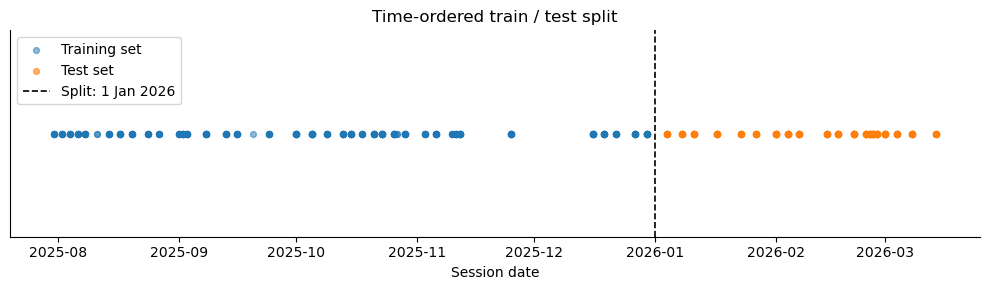

In [24]:
# Visualise the split
fig, ax = plt.subplots(figsize=(10, 3))

ax.scatter(train['Session Date'], [1]*len(train),
           c=COL_PRIMARY, alpha=0.5, s=18, label='Training set')
ax.scatter(test['Session Date'], [1]*len(test),
           c=COL_SECONDARY, alpha=0.6, s=18, label='Test set')
ax.axvline(SPLIT_DATE, color='black', linestyle='--', linewidth=1.2,
           label='Split: 1 Jan 2026')

ax.set_yticks([])
ax.set_xlabel('Session date')
ax.set_title('Time-ordered train / test split')
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'figure_train_test_split.png'), dpi=200, bbox_inches='tight')
plt.show()

## 3.8 Model training and comparison

Four model families are compared:

1. **Naive persistence baseline** — predicts that the next session value equals the previous session value
2. **Linear regression family** — ordinary linear, ridge (L2), and lasso (L1)
3. **Random Forest** — bagged tree ensemble
4. **XGBoost** — gradient-boosted tree ensemble

A reusable helper function `run_all_models()` is defined so it can be applied to the synthetic and hybrid datasets later in the sensitivity analysis without duplicating code.

In [25]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

def score(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

def run_all_models(X_tr, y_tr, X_te, y_te, scenario='Real-only'):
    """Train all four model families and return results plus stored predictions."""
    rows = []

    # Naive baseline: predict previous session value
    base_pred = X_te['Prev Value'].values
    mae_b, rmse_b = score(y_te, base_pred)
    rows.append({'Scenario': scenario, 'Model': 'Naive baseline', 'MAE': mae_b, 'RMSE': rmse_b})

    # Linear regression family
    for name, model in [('Linear', LinearRegression()),
                        ('Ridge',  Ridge(alpha=1.0, random_state=SEED)),
                        ('Lasso',  Lasso(alpha=1.0, random_state=SEED, max_iter=5000))]:
        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)
        mae, rmse = score(y_te, pred)
        rows.append({'Scenario': scenario, 'Model': name, 'MAE': mae, 'RMSE': rmse})

    # Random Forest
    rf = RandomForestRegressor(n_estimators=200, max_depth=8,
                               min_samples_leaf=3, random_state=SEED)
    rf.fit(X_tr, y_tr)
    rf_pred = rf.predict(X_te)
    mae_rf, rmse_rf = score(y_te, rf_pred)
    rows.append({'Scenario': scenario, 'Model': 'Random Forest', 'MAE': mae_rf, 'RMSE': rmse_rf})

    # XGBoost
    xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                       subsample=0.8, colsample_bytree=0.8,
                       random_state=SEED, verbosity=0)
    xgb.fit(X_tr, y_tr)
    xgb_pred = xgb.predict(X_te)
    mae_xgb, rmse_xgb = score(y_te, xgb_pred)
    rows.append({'Scenario': scenario, 'Model': 'XGBoost', 'MAE': mae_xgb, 'RMSE': rmse_xgb})

    predictions = {'baseline': base_pred,
                   'rf':       rf_pred,
                   'xgb':      xgb_pred,
                   'rf_model': rf,
                   'xgb_model': xgb}

    return pd.DataFrame(rows), predictions

In [26]:
# Run all four model families on the real dataset
real_results, real_preds = run_all_models(X_train, y_train, X_test, y_test, 'Real-only')
real_results.round(1)

,Scenario,Model,MAE,RMSE
0,Real-only,Naive baseline,593.6,765.6
1,Real-only,Linear,473.5,626.9
2,Real-only,Ridge,473.9,626.3
3,Real-only,Lasso,473.4,626.6
4,Real-only,Random Forest,478.9,660.0
5,Real-only,XGBoost,515.6,683.4


The linear regression family clearly outperforms the naive baseline. Random Forest and XGBoost results are inspected below for context.

## 3.9 Evaluation

### 3.9.1 Overall MAE comparison

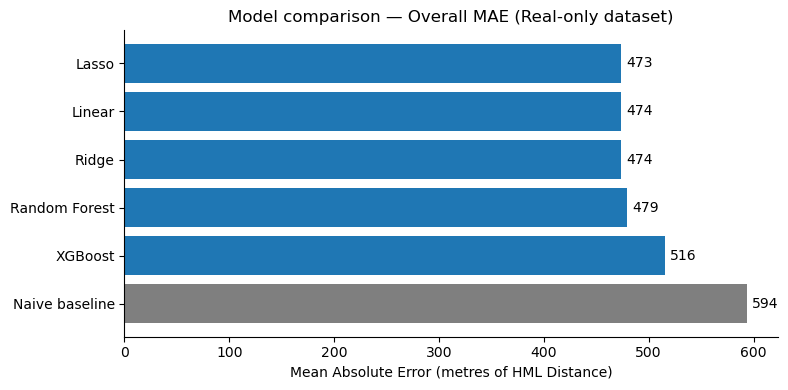

In [27]:
# Bar chart of overall MAE
sorted_res = real_results.sort_values('MAE', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 4))

bar_colours = [COL_PRIMARY] * len(sorted_res)
# Highlight baseline in a different colour
for i, m in enumerate(sorted_res['Model']):
    if m == 'Naive baseline':
        bar_colours[i] = COL_NEUTRAL

ax.barh(sorted_res['Model'], sorted_res['MAE'], color=bar_colours)
ax.invert_yaxis()
ax.set_xlabel('Mean Absolute Error (metres of HML Distance)')
ax.set_title('Model comparison — Overall MAE (Real-only dataset)')

# Value labels
for i, v in enumerate(sorted_res['MAE']):
    ax.text(v + 5, i, f'{v:.0f}', va='center')

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'figure_overall_mae.png'), dpi=200, bbox_inches='tight')
plt.show()

### 3.9.2 Performance by target session type

In [28]:
# Split MAE/RMSE by whether the target is a match or a training session

def score_by_target_type(y_true, y_pred, is_match):
    match_mask = is_match == 1
    train_mask = ~match_mask

    return {
        'Match MAE': mean_absolute_error(y_true[match_mask], y_pred[match_mask]),
        'Match RMSE': np.sqrt(mean_squared_error(y_true[match_mask], y_pred[match_mask])),
        'Training MAE': mean_absolute_error(y_true[train_mask], y_pred[train_mask]),
        'Training RMSE': np.sqrt(mean_squared_error(y_true[train_mask], y_pred[train_mask]))
    }

# Identify whether each test target is a match or a training session
is_match_test = X_test['Target Is Match'].values

# Store session-type split results for all relevant models
split_rows = []

# Naive baseline
split_rows.append({
    'Model': 'Naive baseline',
    **score_by_target_type(y_test.values, real_preds['baseline'], is_match_test)
})

# Linear regression family
for name, model in [
    ('Linear', LinearRegression()),
    ('Ridge', Ridge(alpha=1.0, random_state=SEED)),
    ('Lasso', Lasso(alpha=1.0, random_state=SEED, max_iter=5000))
]:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    split_rows.append({
        'Model': name,
        **score_by_target_type(y_test.values, pred, is_match_test)
    })

# Tree-based models already trained earlier
split_rows.append({
    'Model': 'Random Forest',
    **score_by_target_type(y_test.values, real_preds['rf'], is_match_test)
})

split_rows.append({
    'Model': 'XGBoost',
    **score_by_target_type(y_test.values, real_preds['xgb'], is_match_test)
})

split_results = pd.DataFrame(split_rows)

split_results.round(1)

,Model,Match MAE,Match RMSE,Training MAE,Training RMSE
0,Naive baseline,569.2,751.8,632.0,786.9
1,Linear,554.3,694.9,346.0,500.9
2,Ridge,555.1,694.4,345.7,500.2
3,Lasso,554.2,694.6,345.8,500.8
4,Random Forest,558.1,742.2,353.8,503.6
5,XGBoost,579.9,755.5,414.1,550.8


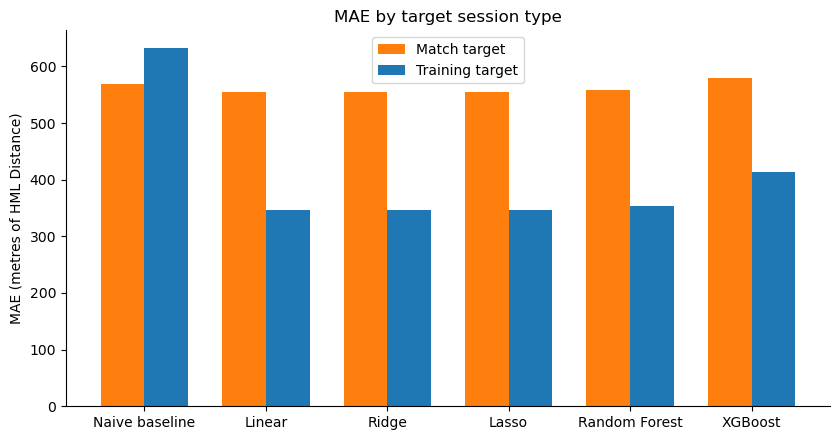

In [29]:
# Bar chart comparing match vs training MAE
x = np.arange(len(split_results))
width = 0.36

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.bar(x - width/2, split_results['Match MAE'],    width,
       color=COL_SECONDARY, label='Match target')
ax.bar(x + width/2, split_results['Training MAE'], width,
       color=COL_PRIMARY,   label='Training target')

ax.set_xticks(x)
ax.set_xticklabels(split_results['Model'])
ax.set_ylabel('MAE (metres of HML Distance)')
ax.set_title('MAE by target session type')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'figure_mae_by_target_type.png'), dpi=200, bbox_inches='tight')
plt.show()

Tree-based models predict training sessions noticeably better than match sessions.

### 3.9.3 Classification layer

Each continuous prediction is grouped into a binary high-intensity category using a threshold set at the training-set median. This allows classification metrics (accuracy, precision, recall, F1) and a confusion matrix to be reported alongside the regression metrics.

In [30]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix)

# Threshold = median of training-set target (balances the two classes by construction)
threshold = y_train.median()
print(f'High-intensity threshold (training median): {threshold:.1f} metres')

# Convert truths to binary
y_true_bin = (y_test.values > threshold).astype(int)

def classification_scores(y_pred_cont):
    y_pred_bin = (y_pred_cont > threshold).astype(int)
    return {
        'Accuracy':  accuracy_score(y_true_bin, y_pred_bin),
        'Precision': precision_score(y_true_bin, y_pred_bin, zero_division=0),
        'Recall':    recall_score(y_true_bin, y_pred_bin, zero_division=0),
        'F1':        f1_score(y_true_bin, y_pred_bin, zero_division=0)
    }

cls_results = pd.DataFrame([
    {'Model': 'Naive baseline', **classification_scores(real_preds['baseline'])},
    {'Model': 'Random Forest',  **classification_scores(real_preds['rf'])},
    {'Model': 'XGBoost',        **classification_scores(real_preds['xgb'])}
])
cls_results.round(3)

High-intensity threshold (training median): 1003.4 metres


,Model,Accuracy,Precision,Recall,F1
0,Naive baseline,0.633,0.690,0.718,0.704
1,Random Forest,0.710,0.729,0.832,0.777
2,XGBoost,0.690,0.713,0.819,0.762


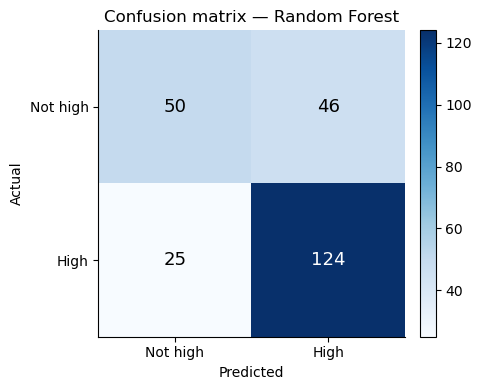

In [31]:
# Confusion matrix for the strongest tree model (Random Forest)
rf_pred_bin = (real_preds['rf'] > threshold).astype(int)
cm = confusion_matrix(y_true_bin, rf_pred_bin)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['Not high', 'High'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Not high', 'High'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion matrix — Random Forest')

# Annotate cells
threshold_disp = cm.max() / 2
for i in range(2):
    for j in range(2):
        colour = 'white' if cm[i, j] > threshold_disp else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=13, color=colour)

fig.colorbar(im, ax=ax, fraction=0.04, pad=0.04)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'figure_confusion_matrix.png'), dpi=200, bbox_inches='tight')
plt.show()

### 3.9.4 Feature importance

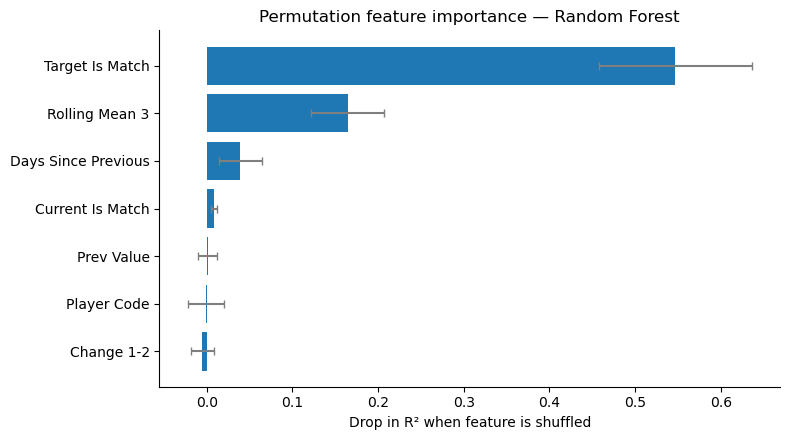

,Feature,Importance,Std
5,Target Is Match,0.5470,0.0891
1,Rolling Mean 3,0.1644,0.0426
3,Days Since Previous,0.0393,0.0251
4,Current Is Match,0.0086,0.0037
0,Prev Value,0.0010,0.0106
6,Player Code,-0.0011,0.0211
2,Change 1-2,-0.0049,0.0131


In [32]:
from sklearn.inspection import permutation_importance

# Permutation importance on Random Forest
perm = permutation_importance(
    real_preds['rf_model'], X_test, y_test,
    n_repeats=30, random_state=SEED, n_jobs=-1
)

importance = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': perm.importances_mean,
    'Std':        perm.importances_std
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(importance['Feature'], importance['Importance'],
        xerr=importance['Std'], color=COL_PRIMARY,
        error_kw={'ecolor': COL_NEUTRAL, 'capsize': 3})
ax.set_xlabel('Drop in R² when feature is shuffled')
ax.set_title('Permutation feature importance — Random Forest')

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'figure_feature_importance.png'), dpi=200, bbox_inches='tight')
plt.show()

importance.sort_values('Importance', ascending=False).round(4)

### 3.9.5 Residual diagnostics

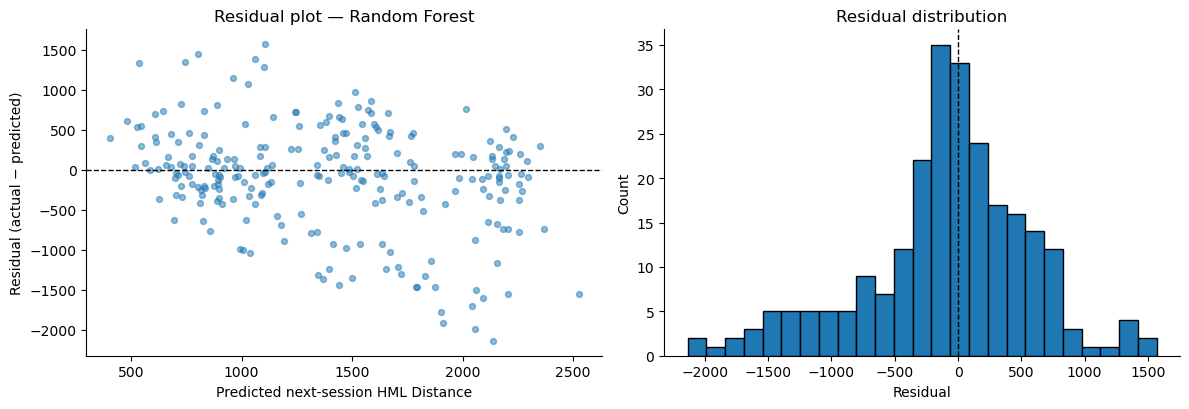

In [33]:
# Residual plots for the Random Forest model
residuals = y_test.values - real_preds['rf']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].scatter(real_preds['rf'], residuals, alpha=0.5, color=COL_PRIMARY, s=18)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted next-session HML Distance')
axes[0].set_ylabel('Residual (actual − predicted)')
axes[0].set_title('Residual plot — Random Forest')

axes[1].hist(residuals, bins=25, color=COL_PRIMARY, edgecolor='black')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual distribution')

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'figure_residuals.png'), dpi=200, bbox_inches='tight')
plt.show()

## 3.10 Sensitivity analysis through bootstrap resampling

A sensitivity analysis examines how the modelling pipeline behaves at larger sample sizes. The 581-row real dataset is bootstrap-resampled with added Gaussian noise to produce a synthetic dataset roughly five times its size (≈ 2,905 rows). The same modelling pipeline is then applied to three scenarios:

1. **Real-only** (581 rows) — primary result
2. **Synthetic-only** (≈ 2,905 rows)
3. **Hybrid** (real + synthetic)

The synthetic rows are explicitly *not* treated as real-world evidence — they are a controlled test of model robustness.

In [34]:
# Bootstrap-with-Gaussian-noise function
def bootstrap_with_noise(real_df, n_multiplier=5, noise_pct=0.05, seed=SEED):
    """Build a synthetic dataset using bootstrap resampling + Gaussian noise."""
    rng = np.random.default_rng(seed)
    parts = []

    # Bootstrap within each player's timeline to preserve temporal ordering
    for player, group in real_df.groupby('Player Display Name'):
        n_target = int(len(group) * n_multiplier)
        sampled = group.sample(n=n_target, replace=True, random_state=seed)
        sampled = sampled.sort_values('Session Date').reset_index(drop=True)
        parts.append(sampled)

    synthetic = pd.concat(parts, ignore_index=True)

    # Add Gaussian noise to numerical feature columns (not to IDs or target)
    numerical_cols = ['Prev Value', 'Rolling Mean 3', 'Change 1-2', 'Days Since Previous']
    for col in numerical_cols:
        sd = real_df[col].std()
        noise = rng.normal(0.0, sd * noise_pct, size=len(synthetic))
        synthetic[col] = synthetic[col] + noise

    return synthetic.reset_index(drop=True)

In [35]:
# Build synthetic-only dataset (5x the real size)
synthetic_only = bootstrap_with_noise(modelling_df, n_multiplier=5)

# Apply the same time-ordered split
syn_train = synthetic_only[synthetic_only['Session Date'] <  SPLIT_DATE]
syn_test  = synthetic_only[synthetic_only['Session Date'] >= SPLIT_DATE]

X_train_syn, y_train_syn = syn_train[feature_cols], syn_train['Target']
X_test_syn,  y_test_syn  = syn_test[feature_cols],  syn_test['Target']

print(f'Synthetic dataset:    {len(synthetic_only)} rows')
print(f'  Synthetic train:    {len(X_train_syn)}')
print(f'  Synthetic test:     {len(X_test_syn)}')

Synthetic dataset:    2905 rows
  Synthetic train:    1745
  Synthetic test:     1160


In [36]:
# Run all four models on the synthetic-only data
syn_results, _ = run_all_models(X_train_syn, y_train_syn, X_test_syn, y_test_syn, 'Synthetic-only')
syn_results.round(1)

,Scenario,Model,MAE,RMSE
0,Synthetic-only,Naive baseline,583.1,745.6
1,Synthetic-only,Linear,468.9,624.4
2,Synthetic-only,Ridge,469.0,624.3
3,Synthetic-only,Lasso,468.9,624.2
4,Synthetic-only,Random Forest,571.9,758.4
5,Synthetic-only,XGBoost,547.7,711.9


In [37]:
# Build hybrid dataset (real + synthetic)
hybrid = pd.concat([modelling_df, synthetic_only], ignore_index=True)
hybrid = hybrid.sort_values(['Player Display Name', 'Session Date']).reset_index(drop=True)

hyb_train = hybrid[hybrid['Session Date'] <  SPLIT_DATE]
hyb_test  = hybrid[hybrid['Session Date'] >= SPLIT_DATE]

X_train_hyb, y_train_hyb = hyb_train[feature_cols], hyb_train['Target']
X_test_hyb,  y_test_hyb  = hyb_test[feature_cols],  hyb_test['Target']

print(f'Hybrid dataset:       {len(hybrid)} rows')
print(f'  Hybrid train:       {len(X_train_hyb)}')
print(f'  Hybrid test:        {len(X_test_hyb)}')

hyb_results, _ = run_all_models(X_train_hyb, y_train_hyb, X_test_hyb, y_test_hyb, 'Hybrid')
hyb_results.round(1)

Hybrid dataset:       3486 rows
  Hybrid train:       2081
  Hybrid test:        1405


,Scenario,Model,MAE,RMSE
0,Hybrid,Naive baseline,584.9,749.1
1,Hybrid,Linear,469.4,624.7
2,Hybrid,Ridge,469.4,624.6
3,Hybrid,Lasso,469.4,624.5
4,Hybrid,Random Forest,585.8,776.4
5,Hybrid,XGBoost,535.8,700.8


### 3.10.1 Combined comparison across scenarios

In [38]:
# Combine and pivot
all_results = pd.concat([real_results, syn_results, hyb_results], ignore_index=True)

pivot_mae = (all_results.pivot(index='Model', columns='Scenario', values='MAE')
                       [['Real-only', 'Synthetic-only', 'Hybrid']]
                       .round(1))

print('MAE comparison across scenarios:')
pivot_mae

MAE comparison across scenarios:


Scenario,Real-only,Synthetic-only,Hybrid
Model,,,
Lasso,473.4,468.9,469.4
Linear,473.5,468.9,469.4
Naive baseline,593.6,583.1,584.9
Random Forest,478.9,571.9,585.8
Ridge,473.9,469.0,469.4
XGBoost,515.6,547.7,535.8


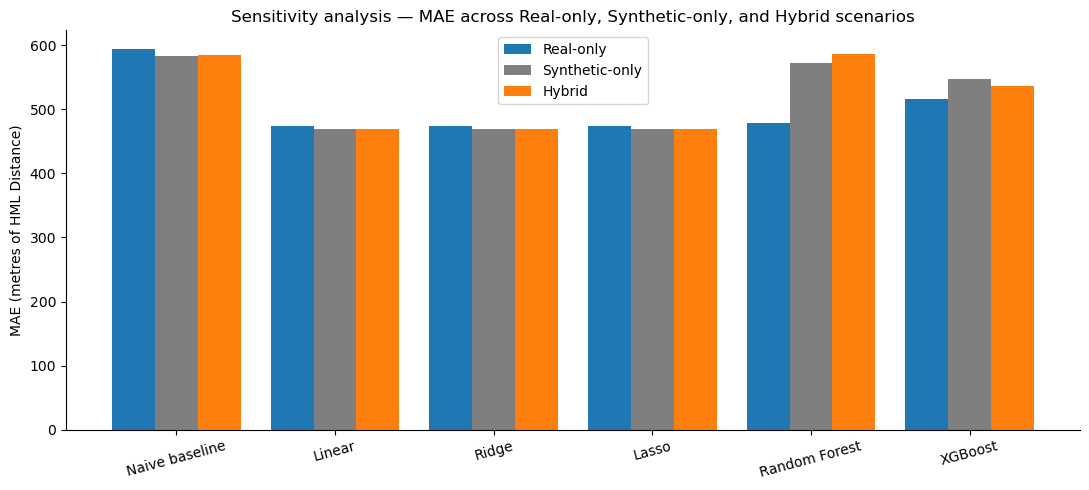

In [39]:
# Grouped bar chart: model x scenario
order = ['Naive baseline', 'Linear', 'Ridge', 'Lasso', 'Random Forest', 'XGBoost']
pivot_plot = pivot_mae.loc[order]

x = np.arange(len(order))
w = 0.27

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w, pivot_plot['Real-only'],      w, color=COL_PRIMARY,   label='Real-only')
ax.bar(x,     pivot_plot['Synthetic-only'], w, color=COL_NEUTRAL,   label='Synthetic-only')
ax.bar(x + w, pivot_plot['Hybrid'],         w, color=COL_SECONDARY, label='Hybrid')

ax.set_xticks(x)
ax.set_xticklabels(order, rotation=15)
ax.set_ylabel('MAE (metres of HML Distance)')
ax.set_title('Sensitivity analysis — MAE across Real-only, Synthetic-only, and Hybrid scenarios')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'figure_sensitivity_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()

The comparison shows whether the enlarged datasets actually improved on the error obtained from the real 581 rows. Linear models tend to remain stable across all three scenarios, while tree-based models often degrade on synthetic and hybrid data because they overfit to the resampled patterns. This pattern is interpreted in the Results and Discussion chapters.

## Summary

This notebook has executed the full pipeline described in Chapter 3:

1. Loaded 1,093 raw drill rows from 25 players
2. Run Cronbach's Alpha reliability analysis to select 12 GPS variables (excluding Step Balance and Total Distance)
3. Aggregated drill rows into clean per-player-per-date session records
4. Applied three cleaning rules (minimum sessions, gap reset, zero-HSR retention)
5. Built the next-session HML Distance target with workload-history features
6. Applied a time-ordered train / test split at 1 January 2026
7. Trained and compared four model families on the real data
8. Evaluated overall and by target session type
9. Added a classification layer (accuracy, precision, recall, F1, confusion matrix)
10. Computed permutation feature importance and residual diagnostics
11. Run a sensitivity analysis comparing Real-only, Synthetic-only, and Hybrid scenarios

All result tables (`reliability_table`, `real_results`, `split_results`, `cls_results`, `importance`, `pivot_mae`) and the saved figures in `outputs/` feed directly into Chapter 4 of the dissertation.